# MLLM-as-Judge


## Show diff results side by side

In [24]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_images_with_labels_and_instruction(
    img_paths,
    labels,
    instruction,
    save_path=None,
    figsize=(18, 6),
    title_fontsize=12,
    instruction_fontsize=14
):
    """
    img_paths: 图片路径列表
    labels: 每张图下方的标签（与 img_paths 对应）
    instruction: 显示在整个图像下方的一句话
    save_path: 保存路径（自动创建目录）
    figsize: 图像整体大小
    """

    assert len(img_paths) == len(labels), "img_paths 和 labels 长度必须一致"

    images = [Image.open(p) for p in img_paths]
    n = len(images)

    plt.figure(figsize=figsize)

    # 显示每张图和对应label
    for i, (img, label) in enumerate(zip(images, labels)):
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(label, fontsize=title_fontsize)

    # 在下方添加 instruction（全局居中）
    plt.figtext(
        0.5,          # X 坐标 (0~1)，0.5 为居中
        0.01,         # Y 坐标，越小越靠下
        f"Instruction: {instruction}",
        ha="center", fontsize=instruction_fontsize
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # 为底部instruction留空间

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved → {save_path}")

    plt.show()


In [69]:
# editing & ctrl gen
SSIM = 0.024299736651645934
LPIPS = 0.9281351898210922

# t2i
clipscore=0.369384765625
aesthetic_score=0.8755626082420349
lpips_vs_blank=0.6704482436180115

# inpainting
masked_lpips=0.09256194531917572
bg_lpips=0.5213004946708679
overall_lpips=0.6556756496429443
masked_ssim=0.8854566912840244
bg_ssim=0.37638528955134737
l1_mask=9.30494213104248
l2_mask=708.4088745117188

alpha = 0.6
score_lama = 0.6445
score_repaint = 0.8757
score_diffedit = 0.8172
score_glide = 0.5310
score_ip2p = 0.8780
score_sd15 = 0.5197
score_sdxl = 0.3139
score_sdrf = 0.5735
score_sdca = 0.5133



finalscore = 0.5 * clipscore + 0.3 * aesthetic_score + 0.2 * (1 - lpips_vs_blank)
FinalScore = 0.35 * masked_ssim + 0.25 * (1 - masked_lpips) + 0.15 * (1 - l1_mask) + 0.10 * bg_ssim + 0.10 * (1 - bg_lpips) + 0.05 * (1 - overall_lpips) 

FinalScore #sd15 0.10507959675778786 sdxl 0.37152969017867915

-0.6062472670308567

Saved → Model/t2i/comp_results/3361210233_962d630ec5.png


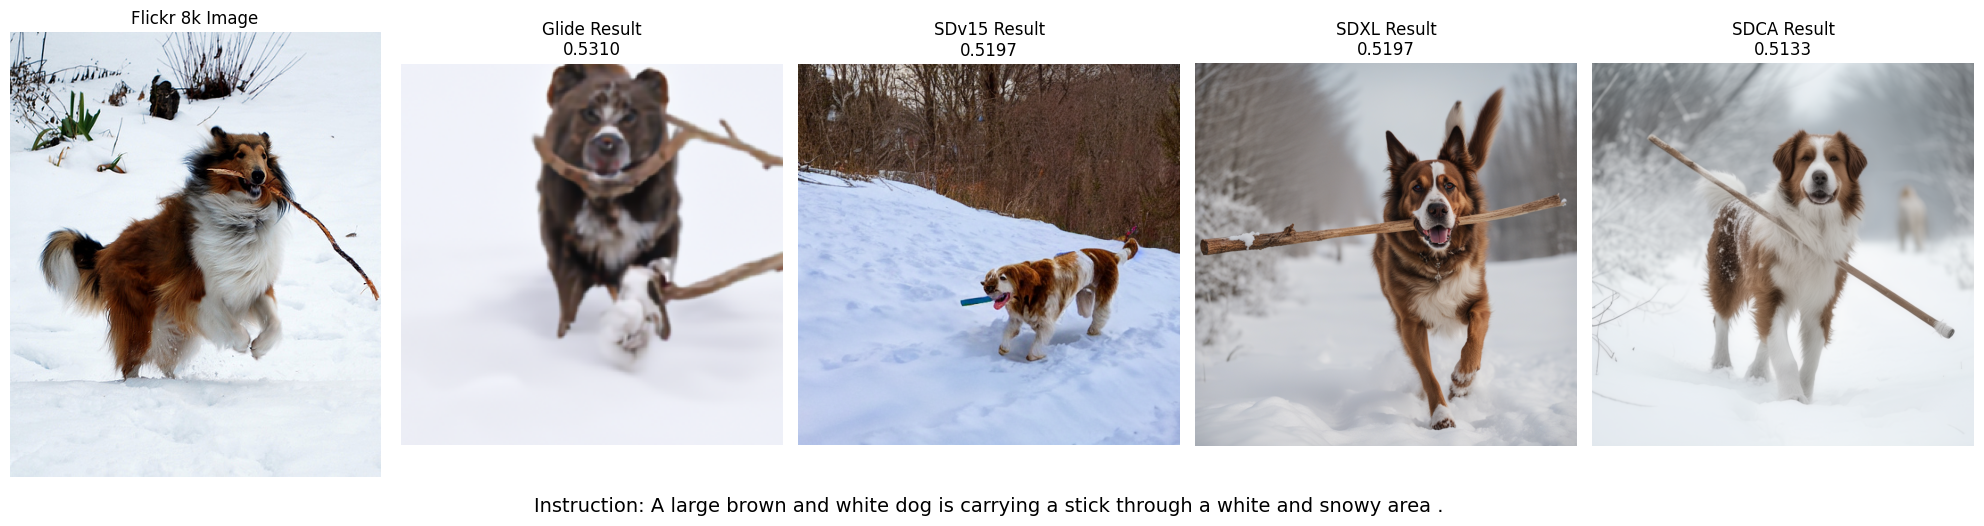

In [ ]:
# labels = [
#     f"SD15-i2i\nScore: {score_sd15:.3f}",
#     f"SDXL-i2i\nScore: {score_sdxl:.3f}",
#     f"IP2P\nScore: {score_ip2p:.3f}",
# ]

img_path = [
    "mini_data/t2i/selected_100_images/3361210233_962d630ec5.jpg",
    "Model/ctrl_gen/results/glide/3361210233_962d630ec5.png",
    "Model/ctrl_gen/results/sd15/3361210233_962d630ec5.png",
    "Model/ctrl_gen/results/sdxl/3361210233_962d630ec5.png",
    "Model/t2i/results/stb_cas/3361210233_962d630ec5.png"

]

labels = [
    f"Flickr 8k Image",
    f"Glide Result\n{score_glide:.4f}",
    f"SDv15 Result\n{score_sd15:.4f}",
    f"SDXL Result\n{score_sdxl:.4f}",
    f"SDCA Result\n{score_sdca:.4f}"
]

instruction = "A large brown and white dog is carrying a stick through a white and snowy area ."

save_path = "Model/t2i/comp_results/3361210233_962d630ec5.png"
os.makedirs(os.path.dirname(save_path), exist_ok=True)

show_images_with_labels_and_instruction(
    img_path,
    labels=labels,
    instruction=instruction,
    save_path=save_path,
    figsize=(20, 5)
)

## Ctrl generation show

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import os

def show_images_with_labels_and_instruction(
    img_paths,
    labels,
    instruction,
    save_path=None,
    figsize=(18, 6),
    title_fontsize=12,
    instruction_fontsize=14
):
    """
    img_paths: 图片路径列表
    labels: 每张图下方的标签（与 img_paths 对应）
    instruction: 显示在整个图像下方的一句话
    save_path: 保存路径（自动创建目录）
    figsize: 图像整体大小
    """

    assert len(img_paths) == len(labels), "img_paths 和 labels 长度必须一致"

    images = [Image.open(p) for p in img_paths]
    n = len(images)

    plt.figure(figsize=figsize)

    # 显示每张图和对应label
    for i, (img, label) in enumerate(zip(images, labels)):
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(label, fontsize=title_fontsize)

    # 在下方添加 instruction（全局居中）
    plt.figtext(
        0.5,          # X 坐标 (0~1)，0.5 为居中
        0.01,         # Y 坐标，越小越靠下
        f"Instruction: {instruction}",
        ha="center", fontsize=instruction_fontsize
    )

    plt.tight_layout(rect=[0, 0.05, 1, 1])  # 为底部instruction留空间

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved → {save_path}")

    plt.show()
# show 
cond_sig = ["canny", "depth", "pose"]
show_num = 2
count = 0

for cond in cond_sig:
    img_lists = os.listdir(f"mini_data/ctrl_gen/{cond}/images")

    for img in img_lists:
        if count >= show_num:
            break
        count += 1
        if cond == "depth":
            img_path = [
                f"mini_data/ctrl_gen/{cond}/images/{img}",
                f"mini_data/ctrl_gen/{cond}/conditions/{img}",
                f"Model/ctrl_gen/results/{cond}/sd15/{img.replace('.jpg', '.png')}",
                f"Model/ctrl_gen/results/{cond}/sd15/{img.replace('.jpg', '_sd15.png')}",
            ] 
        else:
            img_path = [
                f"mini_data/ctrl_gen/{cond}/images/{img}",
                f"mini_data/ctrl_gen/{cond}/conditions/{img}",
                f"Model/ctrl_gen/results/{cond}/sd15/{img.replace('.jpg', '_sd15.png')}",
                f"Model/ctrl_gen/results/{cond}/sd15/{img.replace('.jpg', '.png')}",
            ]

        labels = [
            f"{cond.capitalize()} Image",
            f"{cond.capitalize()} Condition",
            f"SDv15 Improved Result",
            f"SDv15 Result"
        ]

        save_path = f"Model/ctrl_gen/comp_results/{cond}/{img.replace('.jpg', '.png')}"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)

        show_images_with_labels_and_instruction(
            img_path,
            labels=labels,
            instruction=instruction,
            save_path=save_path,
            figsize=(20, 5)
        )

## Prepare Controllable Generation Datasets

In [ ]:
import os
import shutil

def separate_images_by_extension(source_dir, output_root_dir):
    """
    分离一个文件夹中的图片，根据后缀名将它们移动到目标目录下的子文件夹中。

    参数:
    source_dir (str): 包含待分离图片的源文件夹路径。
    output_root_dir (str): 用于存放分离后图片的根目标文件夹路径。
    """
    
    if not os.path.isdir(source_dir):
        print(f"错误：源文件夹 '{source_dir}' 不存在或不是一个目录。")
        return

    # 确保根目标文件夹存在
    os.makedirs(output_root_dir, exist_ok=True)
    print(f"目标根目录已准备好: {output_root_dir}\n")

    # 定义常见的图片扩展名（可以根据需要添加或修改）
    IMAGE_EXTENSIONS = ('rgb.png', 'depth.png')
    
    file_count = 0
    moved_count = 0
    
    # 遍历源文件夹中的所有文件
    for filename in os.listdir(source_dir):
        file_count += 1
        
        # 获取文件的完整路径
        source_path = os.path.join(source_dir, filename)
        
        # 检查是否是文件
        if os.path.isfile(source_path):
            # 分离文件名和扩展名
            name, ext = filename.split('_')
            print("name, ext", name, ext)
            ext = ext.lower()  # 统一转为小写进行匹配
            
            # 检查是否为定义的图片扩展名
            if ext in IMAGE_EXTENSIONS:
                
                # 1. 确定目标子文件夹名称（使用不带点的扩展名）
                extension_folder_name = ext.strip('.')
                destination_dir = os.path.join(output_root_dir, extension_folder_name)
                
                # 2. 创建目标子文件夹
                os.makedirs(destination_dir, exist_ok=True)
                
                # 3. 确定目标文件路径
                destination_path = os.path.join(destination_dir, filename)
                
                # 4. 移动文件
                try:
                    shutil.move(source_path, destination_path)
                    moved_count += 1
                    print(f"已移动: {filename} -> {extension_folder_name}/")
                except Exception as e:
                    print(f"移动文件 {filename} 时发生错误: {e}")
            
            else:
                print(f"跳过文件: {filename} (非图片扩展名)")

        
                
    print("\n--- 任务总结 ---")
    print(f"扫描文件总数: {file_count}")
    print(f"成功移动图片数: {moved_count}")
    print("所有图片已分离完成。")

1
# --- 配置您的路径 ---
# 1. 待分离图片的源文件夹（例如：您的下载目录）
SOURCE_FOLDER = "mini_data/ctrl_gen/depth"

# 2. 存放分离后图片的根目录（脚本将在其下创建 jpg, png 等子文件夹）
OUTPUT_ROOT_FOLDER = "mini_data/ctrl_gen/depth_separated/conditions"

images = list(os.listdir("mini_data/ctrl_gen/depth_separated/images"))
conditions = list(os.listdir("mini_data/ctrl_gen/depth_separated/conditions"))
print(images[40:50])
print(conditions[40:50])


# 调用函数执行分离
# 建议先用少量测试数据运行，确认路径和逻辑无误
# separate_images_by_extension(SOURCE_FOLDER, OUTPUT_ROOT_FOLDER)

In [ ]:
import os
import random
import numpy as np
from PIL import Image
from controlnet_aux import OpenposeDetector

SRC_DIR = "mini_data/ctrl_gen/val2017"     # COCO 原图文件夹
SAVE_IMG_DIR = "mini_data/ctrl_gen/pose_img"
SAVE_POSE_DIR = "mini_data/ctrl_gen/pose_cond"

os.makedirs(SAVE_IMG_DIR, exist_ok=True)
os.makedirs(SAVE_POSE_DIR, exist_ok=True)

detector = OpenposeDetector.from_pretrained("lllyasviel/ControlNet")

def is_black(img):
    arr = np.array(img)
    return np.max(arr) < 10   # 全黑阈值

# 当前已经生成的 pose（你已有）
existing = len(os.listdir(SAVE_POSE_DIR))
needed = 50 - existing
print(f"已有 {existing} 张可用 pose，还需要 {needed} 张")

all_imgs = [f for f in os.listdir(SRC_DIR) if f.endswith('.jpg')]
random.shuffle(all_imgs)

added = 0

for img_name in all_imgs:
    if added >= needed:
        break

    img_path = os.path.join(SRC_DIR, img_name)
    img = Image.open(img_path).convert("RGB")

    pose = detector(img)

    if is_black(pose):
        continue

    # 保存
    img.save(os.path.join(SAVE_IMG_DIR, img_name))
    pose.save(os.path.join(SAVE_POSE_DIR, img_name))

    added += 1
    print(f"[OK] Added {img_name} ({added}/{needed})")

print("Done. Pose dataset now has 50 valid images.")


In [12]:
import os
import shutil

def rename_files_with_suffix_and_replace(directory, target_suffix, search_string, replace_string, dry_run=True):
    """
    批量移除文件名中在扩展名前的特定后缀标记，并进行字符串替换。

    参数:
    directory (str): 包含文件的目录路径。
    target_suffix (str): 要移除的后缀标记（例如：'_sd15'）。
    search_string (str): 要在文件名中查找并替换的字符串（例如：'old_text'）。
    replace_string (str): 用于替换目标字符串的新字符串（例如：'' 用于删除）。
    dry_run (bool): 如果为 True，只打印操作，不实际执行。
    """
    
    if not os.path.isdir(directory):
        print(f"错误：目录 '{directory}' 不存在或不是一个目录。")
        return

    print(f"\n--- 批量重命名 (Dry Run: {dry_run}) ---")
    print(f"步骤 1：移除后缀: '{target_suffix}'")
    print(f"步骤 2：替换 '{search_string}' 为 '{replace_string}'\n")

    replace_count = 0
    
    for old_filename in os.listdir(directory):
        old_path = os.path.join(directory, old_filename)
        
        if os.path.isfile(old_path):
            current_filename = old_filename
            
            # 1. 移除后缀
            base_name, ext = os.path.splitext(current_filename)
            
            if base_name.endswith(target_suffix):
                # 移除目标后缀
                current_base_name = base_name[:-len(target_suffix)]
            else:
                current_base_name = base_name
                
            # 2. 字符串替换
            if search_string:
                new_base_name = current_base_name.replace(search_string, replace_string)
            else:
                new_base_name = current_base_name

            # 3. 组合新的文件名
            new_filename = new_base_name + ext
            new_path = os.path.join(directory, new_filename)

            # 只有在文件名发生变化时才执行操作
            if old_filename != new_filename:
                print(f"重命名: {old_filename} -> {new_filename}")
                
                if not dry_run:
                    try:
                        shutil.move(old_path, new_path)
                        replace_count += 1
                    except Exception as e:
                        print(f"⚠️ 错误：无法重命名文件 {old_filename}: {e}")
            
    if not dry_run:
        print(f"\n✅ 任务完成：成功重命名了 {replace_count} 个文件。")
    else:
        print("\n✅ 模拟运行完成。请检查结果，并设置 dry_run=False 来实际执行。")


# ===================================================
# --- 配置您的重命名任务 ---
# ===================================================

# 1. 待重命名文件所在的目录
TARGET_DIRECTORY = "Model/ctrl_gen/results/pose/sd15"

# 2. **后缀移除配置**：要移除的后缀标记（例如，移除 xxxxx_sd15.png 中的 _sd15）
SUFFIX_TO_REMOVE = "" 

# 3. **字符串替换配置**：
#    - 要查找并替换的字符串（例如：文件名中的 'v1'）
STRING_TO_SEARCH = "" 
#    - 用于替换的新字符串（例如：如果想删除 'v1'，则设置为 ""）
STRING_TO_REPLACE = "" 

# 4. 模式：
#    True: (默认) 只打印操作，不真正修改文件。
#    False: 实际执行重命名操作。
IS_DRY_RUN = False


# 调用函数执行重命名
# 警告：请务必先将 IS_DRY_RUN 设置为 True 运行一次，确认无误后再改为 False！
root_path = "./Model/inpainting/results"
model = os.listdir(root_path)
# folders = list(os.listdir("./Model/t2i/results/diffedit"))

for m in model:
    # for f in folders:
    if m == "lama":
        SUFFIX_TO_REMOVE = "_inpainted"
        STRING_TO_SEARCH = ""
        STRING_TO_REPLACE = ""
    else:
        continue

    TARGET_DIRECTORY = os.path.join(root_path, m)
    print("Processing folder:", m)

    rename_files_with_suffix_and_replace(
        directory=TARGET_DIRECTORY,
        target_suffix=SUFFIX_TO_REMOVE,
        search_string=STRING_TO_SEARCH,
        replace_string=STRING_TO_REPLACE,
        dry_run=IS_DRY_RUN
    )

Processing folder: lama

--- 批量重命名 (Dry Run: False) ---
步骤 1：移除后缀: '_inpainted'
步骤 2：替换 '' 为 ''

重命名: celeba_00212_inpainted.png -> celeba_00212.png
重命名: celeba_00819_inpainted.png -> celeba_00819.png
重命名: celeba_00869_inpainted.png -> celeba_00869.png
重命名: celeba_00976_inpainted.png -> celeba_00976.png
重命名: celeba_01041_inpainted.png -> celeba_01041.png
重命名: celeba_02848_inpainted.png -> celeba_02848.png
重命名: celeba_03070_inpainted.png -> celeba_03070.png
重命名: celeba_03358_inpainted.png -> celeba_03358.png
重命名: celeba_03648_inpainted.png -> celeba_03648.png
重命名: celeba_04572_inpainted.png -> celeba_04572.png
重命名: celeba_05094_inpainted.png -> celeba_05094.png
重命名: celeba_05231_inpainted.png -> celeba_05231.png
重命名: celeba_06515_inpainted.png -> celeba_06515.png
重命名: celeba_07055_inpainted.png -> celeba_07055.png
重命名: celeba_07164_inpainted.png -> celeba_07164.png
重命名: celeba_07223_inpainted.png -> celeba_07223.png
重命名: celeba_07314_inpainted.png -> celeba_07314.png
重命名: celeba_07623_i

## Generate prompt

In [ ]:
import re

MAX_WORDS = 40

# ===== 可扩展的区域关键词 =====
REGION_KEYWORDS = {
    "shirt": "her shirt",
    "top": "her top",
    "dress": "her outfit",
    "clothes": "her outfit",
    "pants": "her pants",
    "skirt": "her skirt",
    "hair": "her hair",
    "eyes": "her eye region",
    "face": "her face",
    "man": "the man",
    "woman": "the woman",
    "ufo": "the sky area",
    "sky": "the sky area",
    "object": "the target object",
}

# ===== 根据文本推断区域 =====
def detect_region(instruction):
    ins = instruction.lower()
    for k, v in REGION_KEYWORDS.items():
        if k in ins:
            return v
    return "the target region"

# ===== 根据图像语义（你 pipeline 可接 Vision model） =====
def refine_with_position(region, position):
    if "woman" in region and position:
        return f"the woman on the {position} side"
    return region

# ===== 控制词数 =====
def enforce_40_words(text):
    words = text.split()
    if len(words) <= MAX_WORDS:
        return text
    return " ".join(words[:MAX_WORDS])

# ===== 主增强函数 =====
def enhance_prompt(instruction, position="right"):
    region = detect_region(instruction)
    region = refine_with_position(region, position)

    template = (
        "Modify only REGION. "
        "Do not change her body, pose, or background. "
        "Apply this edit: EDIT."
    )

    prompt = template.replace("REGION", region)
    prompt = prompt.replace("EDIT", instruction.strip())

    # 清理空格
    prompt = " ".join(prompt.split())

    # 限制 40 words
    prompt = enforce_40_words(prompt)

    return prompt

# ===== 批处理 =====
def batch_enhance(instructions, positions=None):
    outputs = []
    for i, ins in enumerate(instructions):
        pos = "right"
        if positions and i < len(positions):
            pos = positions[i]
        outputs.append(enhance_prompt(ins, pos))
    return outputs


# ======== 示例 ========
instructions = [
    "let the woman wear a party gown",
    "add a UFO to the sky",
]

positions = ["right", None]  # 你也可以用视觉模型自动生成

enhanced = batch_enhance(instructions, positions)

for p in enhanced:
    print("\nEnhanced Prompt:", p, "\nWords:", len(p.split()))
